# Extended Report — Simulación NVT de 500 ps

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS  
**Temperatura simulada:** 298 K

Simulación NVT extendida a **298 K** con exportación cada **10 fs** (`nstxout = nstvout = 20`,
`dt = 0.0005 ps`) durante **500 ps** (1 000 000 pasos → 50 001 frames).

Se analizan:
1. **Histograma de temperatura** del sistema.
2. **Distribución de las tres componentes de velocidad** ($v_x$, $v_y$, $v_z$) del átomo 16
   (O del carbonilo de ALA-2, $m = 15.999$ u), con ajuste a Maxwell-Boltzmann.
3. **Mapas de Ramachandran** ($\varphi$, $\psi$) de los tres residuos (ALA-2, ARG-3, VAL-4)
   e identificación de las conformaciones más probables.

---

## 1. Importación de librerías y configuración de estilo

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from scipy.stats import norm

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# ── Constantes físicas ─────────────────────────────────────────────────────────
kB       = 1.380649e-23   # J/K
u_to_kg  = 1.66054e-27    # kg/u
nmps_to_ms = 1e3          # 1 nm/ps = 1000 m/s

# ── Parámetros de la simulación ───────────────────────────────────────────────
T_SIM    = 298             # K
DT       = 0.01           # ps (10 fs)
T_TOTAL  = 500            # ps

# ── Átomo seleccionado ─────────────────────────────────────────────────────────
ATOM_ID   = 16
ATOM_TYPE = 'O'
ATOM_RES  = 'ALA-2'
ATOM_MASS = 15.999  # u

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [33]:
def load_xvg(filepath):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    return np.array(data)

# ── Temperatura ────────────────────────────────────────────────────────────────
raw_temp = load_xvg('temp-500ps.xvg')
time_ps  = raw_temp[:, 0]
temp     = raw_temp[:, 1]

# ── Velocidades del átomo 16 ───────────────────────────────────────────────────
raw_vel = load_xvg('veloc-atom16-500ps.xvg')
vx = raw_vel[:, 1]
vy = raw_vel[:, 2]
vz = raw_vel[:, 3]

# ── Ramachandran ───────────────────────────────────────────────────────────────
rama_ala = np.loadtxt('rama-ALA-2.dat')
rama_arg = np.loadtxt('rama-ARG-3.dat')
rama_val = np.loadtxt('rama-VAL-4.dat')

print(f'Temperatura: {len(temp)} frames, t = {time_ps[0]:.2f} – {time_ps[-1]:.2f} ps')
print(f'Velocidades (At. {ATOM_ID}): {len(vx)} frames')
print(f'Ramachandran: ALA-2 = {len(rama_ala)}, ARG-3 = {len(rama_arg)}, VAL-4 = {len(rama_val)} frames')

Temperatura: 50001 frames, t = 0.00 – 500.00 ps
Velocidades (At. 16): 50001 frames
Ramachandran: ALA-2 = 50001, ARG-3 = 50001, VAL-4 = 50001 frames


---
## 3. Histograma de temperatura

La temperatura instantánea del sistema fluctúa alrededor del valor nominal de 298 K
controlada por el termostato v-rescale. Se representa el histograma normalizado con
la distribución esperada para un sistema canónico.

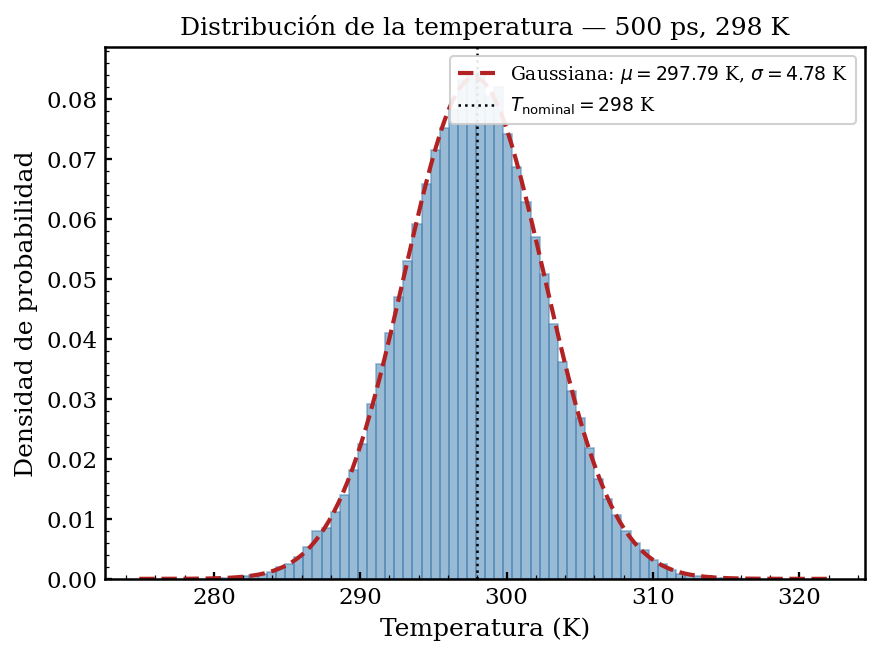

⟨T⟩ = 297.79 ± 4.78 K
Figura guardada como temperature_histogram_500ps.png


In [34]:
mean_T = temp.mean()
std_T  = temp.std()

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.hist(temp, bins=60, density=True, color='steelblue', alpha=0.55,
        edgecolor='steelblue', linewidth=0.8)

x_fit = np.linspace(temp.min() - 5, temp.max() + 5, 300)
ax.plot(x_fit, norm.pdf(x_fit, mean_T, std_T),
        color='firebrick', lw=2, ls='--',
        label=rf'Gaussiana: $\mu={mean_T:.2f}$ K, $\sigma={std_T:.2f}$ K')

ax.axvline(T_SIM, color='black', lw=1.2, ls=':',
           label=rf'$T_{{\mathrm{{nominal}}}} = {T_SIM}$ K')

ax.set_xlabel('Temperatura (K)')
ax.set_ylabel('Densidad de probabilidad')
ax.set_title(f'Distribución de la temperatura — 500 ps, {T_SIM} K')
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('temperature_histogram_500ps.png')
plt.show()
print(f'⟨T⟩ = {mean_T:.2f} ± {std_T:.2f} K')
print('Figura guardada como temperature_histogram_500ps.png')


---
## 4. Distribución de velocidades — Átomo 16 (O, ALA-2)

Histogramas de $v_x$, $v_y$ y $v_z$ del átomo 16
(O del carbonilo del backbone de ALA-2, $m = 15.999$ u), con ajuste a la distribución
de Maxwell-Boltzmann:

$$f(v_x) = \sqrt{\frac{m}{2\pi k_B T}}\,\exp\!\left(-\frac{m\,v_x^2}{2\,k_B T}\right), 
\quad \sigma_{\mathrm{MB}} = \sqrt{\frac{k_B T}{m}}$$

Para el O ($m = 15.999$ u) a 298 K: $\sigma_{\mathrm{MB}} \approx 0.3936$ nm/ps.

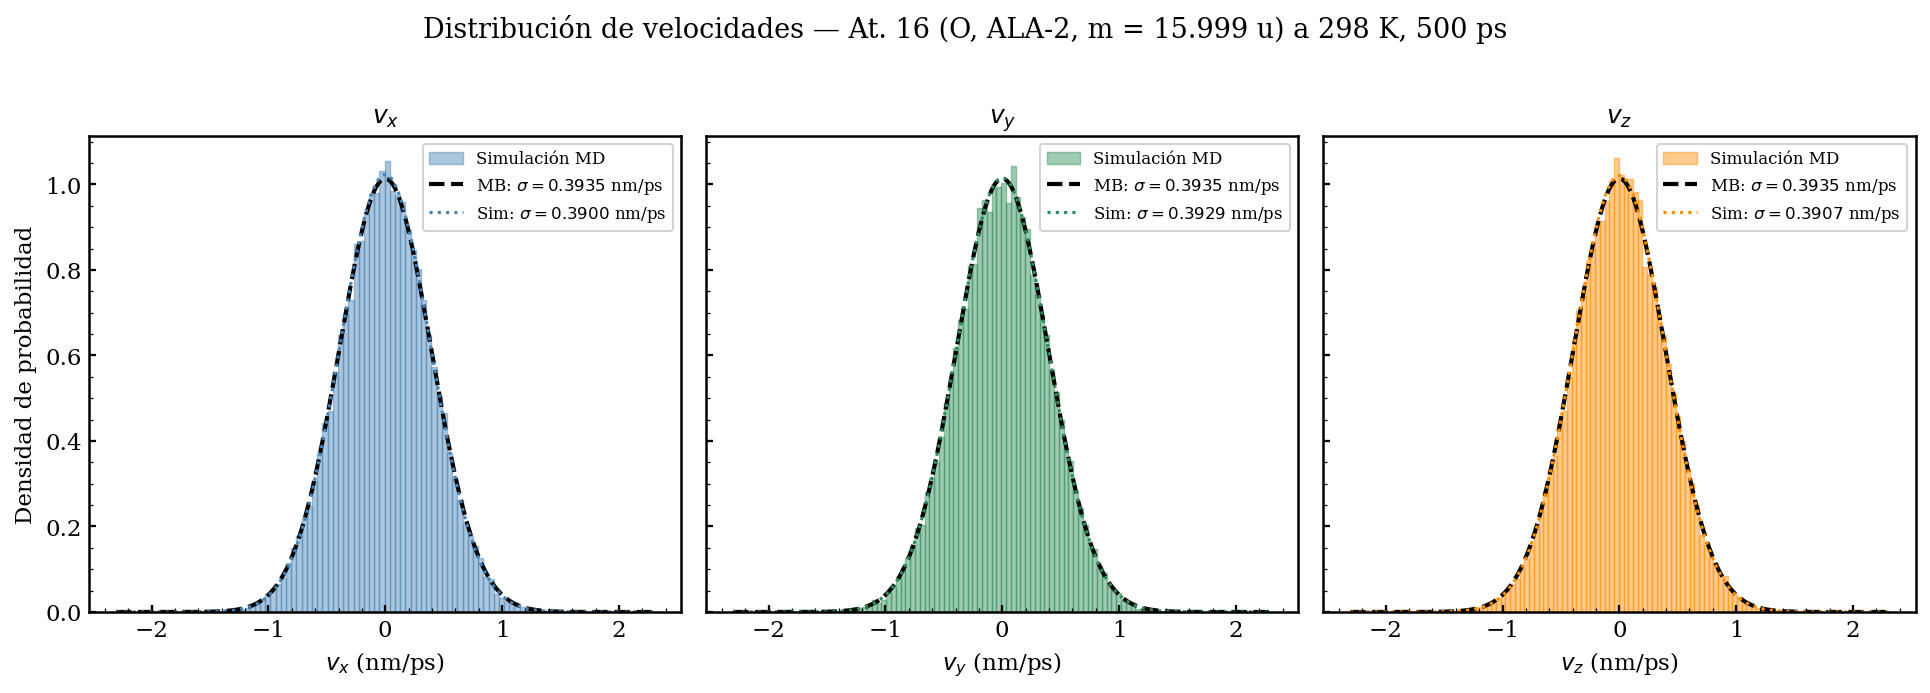

σ_MB teórico = 0.3935 nm/ps
σ_sim(vx) = 0.3900, σ_sim(vy) = 0.3929, σ_sim(vz) = 0.3907 nm/ps
Figura guardada como veloc_3comp_histogram_500ps.png


In [35]:
m_kg = ATOM_MASS * u_to_kg
sigma_MB = np.sqrt(kB * T_SIM / m_kg) / nmps_to_ms   # nm/ps

comp_data   = [vx, vy, vz]
comp_labels = [r'$v_x$', r'$v_y$', r'$v_z$']
comp_colors = ['steelblue', 'seagreen', 'darkorange']

# Rango en x compartido
all_v  = np.concatenate([vx, vy, vz])
x_lim  = np.max(np.abs(all_v)) + 0.3
x_fit  = np.linspace(-x_lim, x_lim, 400)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True, sharex=True)

for ax, v, lbl, col in zip(axes, comp_data, comp_labels, comp_colors):
    # Histograma de la simulación
    ax.hist(v, bins=80, density=True,
            color=col, alpha=0.45, edgecolor=col, linewidth=0.7,
            label='Simulación MD')

    # Curva teórica MB
    ax.plot(x_fit, norm.pdf(x_fit, 0, sigma_MB),
            color='black', lw=2, ls='--',
            label=rf'MB: $\sigma = {sigma_MB:.4f}$ nm/ps')

    # σ de la simulación
    sigma_sim = v.std()
    ax.plot(x_fit, norm.pdf(x_fit, 0, sigma_sim),
            color=col, lw=1.5, ls=':',
            label=rf'Sim: $\sigma = {sigma_sim:.4f}$ nm/ps')

    ax.set_xlabel(f'{lbl} (nm/ps)', fontsize=11)
    ax.set_title(lbl, fontsize=12)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(loc='upper right', fontsize=8, framealpha=0.85)

axes[0].set_ylabel('Densidad de probabilidad', fontsize=11)

fig.suptitle(
    f'Distribución de velocidades — At. {ATOM_ID} '
    f'({ATOM_TYPE}, {ATOM_RES}, m = {ATOM_MASS} u) a {T_SIM} K, '
    f'500 ps',
    fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('veloc_3comp_histogram_500ps.png')
plt.show()
print(f'σ_MB teórico = {sigma_MB:.4f} nm/ps')
print(f'σ_sim(vx) = {vx.std():.4f}, σ_sim(vy) = {vy.std():.4f}, σ_sim(vz) = {vz.std():.4f} nm/ps')
print('Figura guardada como veloc_3comp_histogram_500ps.png')

### 4.1 Resumen estadístico — Temperatura y velocidades

In [36]:
rows = []

# Temperatura
rows.append({
    'Magnitud':    'Temperatura',
    'Unidad':      'K',
    '⟨x⟩':         round(temp.mean(), 3),
    'σ simulación': round(temp.std(), 3),
    'σ teórico':    '—',
    'Mín':          round(temp.min(), 2),
    'Máx':          round(temp.max(), 2),
    'N frames':     len(temp),
})

# Componentes de velocidad
for comp_name, comp_v in [('v_x', vx), ('v_y', vy), ('v_z', vz)]:
    rows.append({
        'Magnitud':    f'{comp_name} (At. {ATOM_ID})',
        'Unidad':      'nm/ps',
        '⟨x⟩':         round(comp_v.mean(), 5),
        'σ simulación': round(comp_v.std(), 4),
        'σ teórico':    round(sigma_MB, 4),
        'Mín':          round(comp_v.min(), 4),
        'Máx':          round(comp_v.max(), 4),
        'N frames':     len(comp_v),
    })

df_summary = pd.DataFrame(rows)

(df_summary.style
    .set_caption('Tabla 1. Estadística descriptiva de temperatura y componentes '
                 f'de velocidad del átomo {ATOM_ID} ({ATOM_TYPE}, {ATOM_RES}) '
                 f'a {T_SIM} K — simulación de 500 ps.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .hide(axis='index')
)

Magnitud,Unidad,⟨x⟩,σ simulación,σ teórico,Mín,Máx,N frames
Temperatura,K,297.786000,4.775000,—,279.910000,317.170000,50001
v_x (At. 16),nm/ps,-0.001470,0.390000,0.393500,-2.004700,1.550300,50001
v_y (At. 16),nm/ps,-0.000160,0.392900,0.393500,-1.691800,1.591300,50001
v_z (At. 16),nm/ps,0.000810,0.390700,0.393500,-1.663000,1.573400,50001


---
## 5. Mapas de Ramachandran

Los ángulos diédricos del backbone $\varphi$ (C–N–C$_\alpha$–C) y $\psi$ (N–C$_\alpha$–C–N)
caracterizan la conformación de cada residuo. Las regiones más pobladas del mapa
de Ramachandran se corresponden con las estructuras secundarias canónicas:

| Conformación | $\varphi$ (°) | $\psi$ (°) |
|:------------|:------------:|:----------:|
| $\alpha_R$ (hélice α derecha) | $-140$ a $-30$ | $-80$ a $+10$ |
| $\alpha_L$ (hélice α izquierda) | $+30$ a $+100$ | $+10$ a $+80$ |
| $\beta$ (lámina β extendida) | $-180$ a $-100$ | $+100$ a $+180$ |
| $\beta'$ (PPII / lámina β) | $-100$ a $-30$ | $+100$ a $+180$ |
| $\delta_R$ (puente C7eq) | $-140$ a $-30$ | $+10$ a $+80$ |

### 5.1 Mapa de densidad suavizado (Gaussiana 2D)

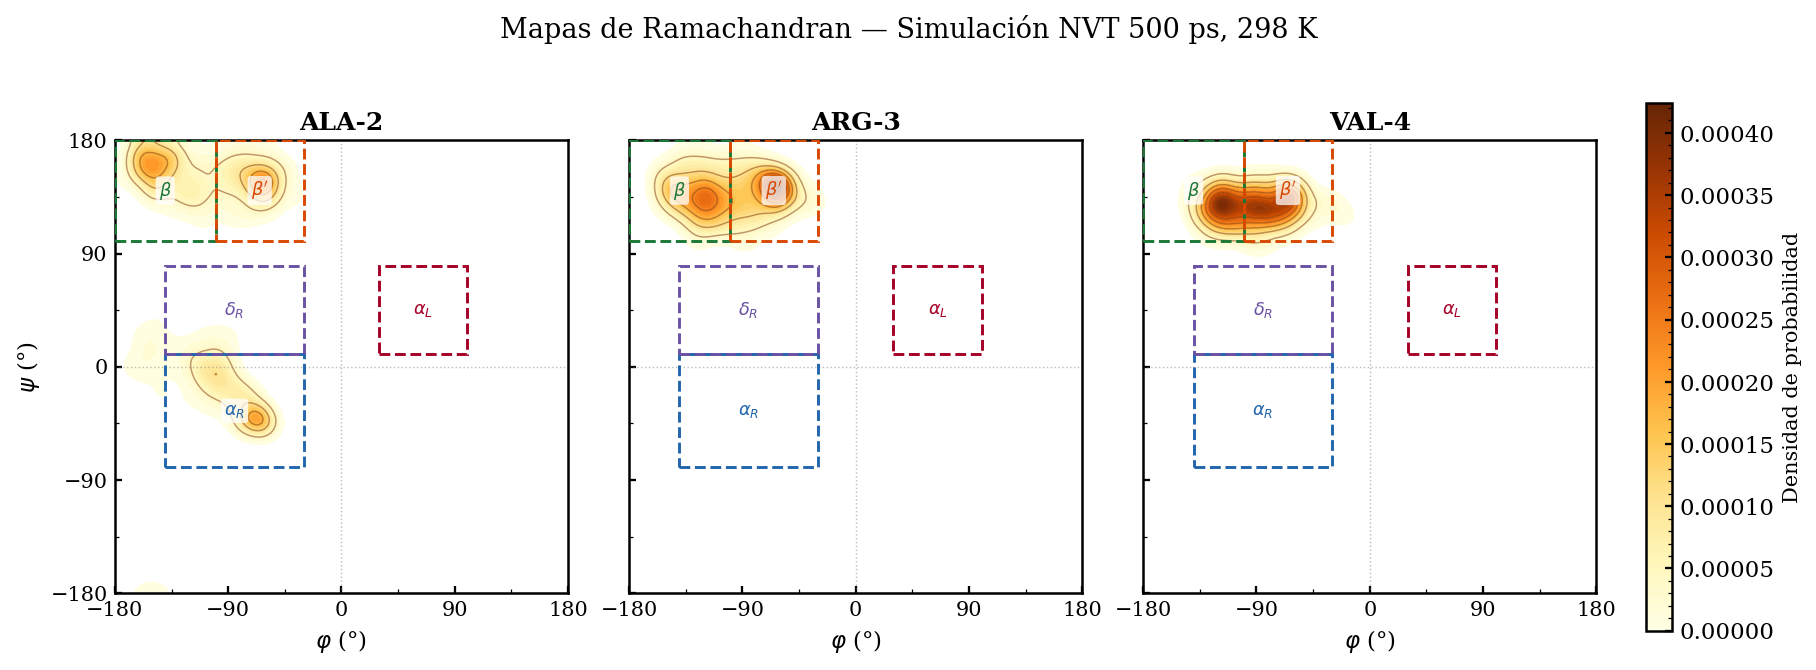

Figura guardada como ramachandran_density_500ps.png


In [37]:
from scipy.ndimage import gaussian_filter

rama_data = [
    ('ALA-2', rama_ala),
    ('ARG-3', rama_arg),
    ('VAL-4', rama_val),
]

# Colores ColorBrewer — bien visibles sobre YlOrBr y sobre fondo blanco
CONF_REGIONS = [
    # (nombre, phi_min, phi_max, psi_min, psi_max, color)
    (r'$\alpha_R$',  -140, -30,  -80,  10,  '#2166ac'),   # azul
    (r'$\beta$',     -180, -100, 100, 180,  '#1b7837'),   # verde oscuro
    (r"$\beta'$",    -100, -30,  100, 180,  '#d94801'),   # naranja oscuro
    (r'$\delta_R$',  -140, -30,   10,  80,  '#6a51a3'),   # violeta
    (r'$\alpha_L$',    30, 100,   10,  80,  '#a50026'),   # rojo oscuro
]

# Pre-calcular histogramas suavizados y vmax global para escala de color consistente
_grids, _edges = [], []
for _, _data in rama_data:
    _H, _xe, _ye = np.histogram2d(_data[:, 1], _data[:, 2], bins=150,
                                   range=[[-180, 180], [-180, 180]], density=True)
    _grids.append((gaussian_filter(_H.T, sigma=2.5), _xe, _ye))
vmax_global = max(g.max() for g, _, _ in _grids)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5),
                         sharey=True, sharex=True,
                         constrained_layout=True)

for ax, (res_name, _), (H_smooth, xedges, yedges) in zip(axes, rama_data, _grids):
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(xc, yc)

    levels_fill = np.linspace(vmax_global * 0.03, vmax_global, 30)
    levels_line = np.linspace(vmax_global * 0.12, vmax_global, 7)

    ax.contourf(X, Y, H_smooth, levels=levels_fill, cmap='YlOrBr', extend='neither')
    ax.contour(X, Y, H_smooth, levels=levels_line, colors='saddlebrown',
               linewidths=0.7, alpha=0.55)

    for (rname, p0, p1, s0, s1, rcol) in CONF_REGIONS:
        rect = plt.Rectangle((p0, s0), p1 - p0, s1 - s0,
                              linewidth=1.4, edgecolor=rcol,
                              facecolor='none', linestyle='--', zorder=3)
        ax.add_patch(rect)
        cx, cy = 0.5 * (p0 + p1), 0.5 * (s0 + s1)
        ax.text(cx, cy, rname, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=rcol, zorder=4,
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                          edgecolor='none', alpha=0.75))

    ax.axhline(0, color='grey', lw=0.7, ls=':', alpha=0.5)
    ax.axvline(0, color='grey', lw=0.7, ls=':', alpha=0.5)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-180, 180)
    ax.set_aspect('equal')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_yticks([-180, -90, 0, 90, 180])
    ax.tick_params(labelsize=10)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(45))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(45))
    ax.set_xlabel(r'$\varphi$ (°)', fontsize=11)
    ax.set_title(res_name, fontsize=12, fontweight='bold', pad=5)

axes[0].set_ylabel(r'$\psi$ (°)', fontsize=11)

sm = plt.cm.ScalarMappable(cmap='YlOrBr',
                            norm=plt.Normalize(vmin=0, vmax=vmax_global))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.85, aspect=20, pad=0.02)
cbar.set_label('Densidad de probabilidad', fontsize=10)
cbar.ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

fig.suptitle(f'Mapas de Ramachandran — Simulación NVT 500 ps, {T_SIM} K',
             fontsize=13)

plt.savefig('ramachandran_density_500ps.png')
plt.show()
print('Figura guardada como ramachandran_density_500ps.png')


### 5.2 Identificación cuantitativa de conformaciones

Se calcula la fracción de frames que caen en cada región conformacional para cada residuo.

In [38]:
def classify_conformation(phi, psi):
    """Clasifica un par (phi, psi) en las regiones conformacionales canónicas."""
    regions = {
        'α_R':   {'phi': (-140, -30), 'psi': (-80,  10)},
        'β':     {'phi': (-180, -100), 'psi': (80,  180)},
        "β'": {'phi': (-100, -30), 'psi': (80,  180)},
        'α_L':   {'phi': (30,  100),  'psi': (10,  80)},
        'δ_R':   {'phi': (-140, -30), 'psi': (10,  80)},
    }
    for name, r in regions.items():
        if (r['phi'][0] <= phi <= r['phi'][1] and
            r['psi'][0] <= psi <= r['psi'][1]):
            return name
    return 'Otra'

conf_rows = []
for res_name, data in rama_data:
    phi_arr = data[:, 1]
    psi_arr = data[:, 2]
    n_total = len(phi_arr)

    classifications = [classify_conformation(p, s) for p, s in zip(phi_arr, psi_arr)]
    unique, counts = np.unique(classifications, return_counts=True)

    for conf, cnt in zip(unique, counts):
        pct = cnt / n_total * 100
        conf_rows.append({
            'Residuo':        res_name,
            'Conformación':   conf,
            'N frames':       cnt,
            'Población (%)':  round(pct, 2),
        })

df_conf = pd.DataFrame(conf_rows)

# Calcular la conformación dominante de cada residuo
dominant = (df_conf[df_conf['Conformación'] != 'Otra']
            .sort_values('Población (%)', ascending=False)
            .groupby('Residuo').first().reset_index())

print('Conformación dominante por residuo:')
for _, row in dominant.iterrows():
    print(f"  {row['Residuo']}: {row['Conformación']} ({row['Población (%)']:.1f}%)")

Conformación dominante por residuo:
  ALA-2: β (33.9%)
  ARG-3: β (49.9%)
  VAL-4: β' (55.8%)


In [39]:
# Pivotar para presentación limpia
df_pivot = df_conf.pivot_table(index='Conformación', columns='Residuo',
                                values='Población (%)', fill_value=0)
# Reordenar columnas
col_order = ['ALA-2', 'ARG-3', 'VAL-4']
df_pivot = df_pivot[[c for c in col_order if c in df_pivot.columns]]

# Reordenar filas: primero las conformaciones conocidas, luego 'Otra'
row_order = ['α_R', 'β', "β'", 'δ_R', 'α_L', 'Otra']
df_pivot = df_pivot.reindex([r for r in row_order if r in df_pivot.index])

(df_pivot.style
    .format('{:.2f}')
    .set_caption('Tabla 2. Población conformacional (%) de cada residuo — '
                 f'simulación NVT de 500 ps a {T_SIM} K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .background_gradient(cmap='YlOrBr', axis=None, vmin=0)
)

Residuo,ALA-2,ARG-3,VAL-4
Conformación,,,
α_R,27.41,0.02,0.00
β,33.90,49.88,42.69
β',27.93,49.16,55.84
δ_R,4.41,0.52,0.06
α_L,0.00,0.00,0.01
Otra,6.36,0.42,1.40


### 5.3 Gráfico de barras — Poblaciones conformacionales

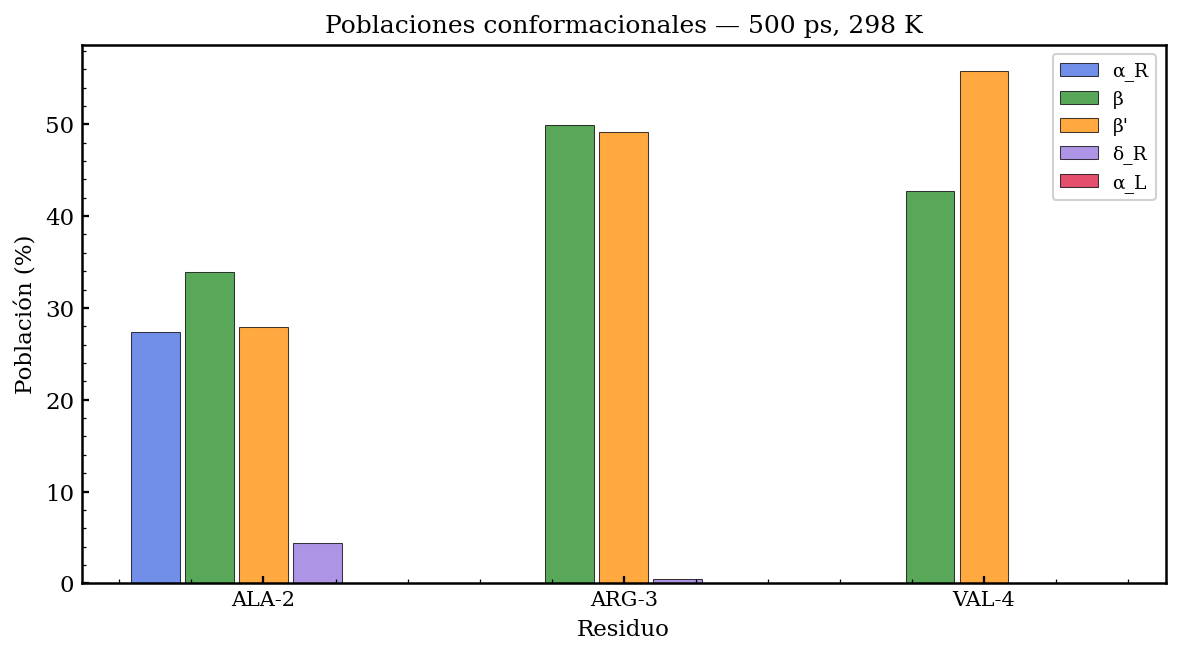

Figura guardada como ramachandran_populations_bars_500ps.png


In [40]:
conf_names = [r for r in row_order if r in df_pivot.index and r != 'Otra']
residues   = col_order
n_conf     = len(conf_names)
n_res      = len(residues)

bar_colors = {
    'α_R':  'royalblue',
    'β':    'forestgreen',
    "β'": 'darkorange',
    'δ_R':  'mediumpurple',
    'α_L':  'crimson',
}

x = np.arange(n_res)
width = 0.75 / n_conf

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, conf in enumerate(conf_names):
    vals = [df_pivot.loc[conf, res] if conf in df_pivot.index else 0 for res in residues]
    offset = (i - (n_conf - 1) / 2) * width
    ax.bar(x + offset, vals, width * 0.9,
           color=bar_colors.get(conf, 'grey'), alpha=0.75,
           edgecolor='black', linewidth=0.5, label=conf)

ax.set_xlabel('Residuo', fontsize=11)
ax.set_ylabel('Población (%)', fontsize=11)
ax.set_title(f'Poblaciones conformacionales — 500 ps, {T_SIM} K', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(residues, fontsize=10)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('ramachandran_populations_bars_500ps.png')
plt.show()
print('Figura guardada como ramachandran_populations_bars_500ps.png')